# GradeScope — 01. Eksploracyjna Analiza Danych (EDA)

**Zbiór danych:** Student Performance Factors — 6607 rekordów, 20 kolumn  
**Cel:** poznanie struktury danych przed preprocessingiem

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styl wykresów
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

# Wczytanie danych
df = pd.read_csv("../data/student_performance.csv")

print(f"Liczba rekordów: {len(df)}")
print(f"Liczba kolumn:   {len(df.columns)}")
df.head()

Liczba rekordów: 6607
Liczba kolumn:   20


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 1. Struktura i typy danych

In [11]:
# Typy danych i podstawowe informacje
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [12]:
# Statystyki opisowe dla kolumn numerycznych
df.describe().round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


In [13]:
# Sprawdzenie brakujących wartości
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Brakujące wartości": missing,
    "Procent (%)": missing_pct
}).query("`Brakujące wartości` > 0")

if missing_df.empty:
    print("Brak brakujących wartości w zbiorze danych.")
else:
    print(missing_df)

                          Brakujące wartości  Procent (%)
Teacher_Quality                           78         1.18
Parental_Education_Level                  90         1.36
Distance_from_Home                        67         1.01


## 2. Zmienna docelowa — próg Pass/Fail = 67

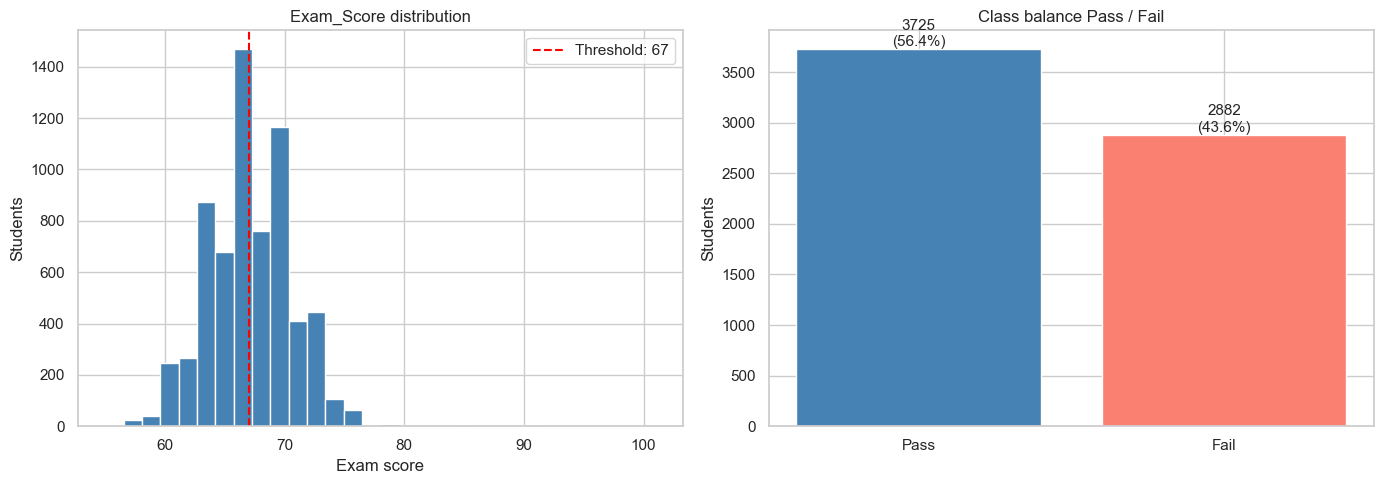

Pass: 3725  |  Fail: 2882
Pass/Fail ratio: 1.29


In [14]:
# Rozkład wyniku egzaminu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["Exam_Score"], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(67, color="red", linestyle="--", linewidth=1.5, label="Threshold: 67")
axes[0].set_title("Exam_Score distribution")
axes[0].set_xlabel("Exam score")
axes[0].set_ylabel("Students")
axes[0].legend()

# Klasyfikacja Pass/Fail — próg 67
df["Pass"] = (df["Exam_Score"] >= 67).map({True: "Pass", False: "Fail"})
counts = df["Pass"].value_counts()
axes[1].bar(counts.index, counts.values, color=["steelblue", "salmon"], edgecolor="white")
for i, (label, val) in enumerate(counts.items()):
    axes[1].text(i, val + 30, f"{val}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=11)
axes[1].set_title("Class balance Pass / Fail")
axes[1].set_ylabel("Students")

plt.tight_layout()
plt.savefig("../report/fig_exam_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Pass: {counts.get('Pass', 0)}  |  Fail: {counts.get('Fail', 0)}")
print(f"Pass/Fail ratio: {counts.get('Pass', 0)/counts.get('Fail', 1):.2f}")

## 3. Rozkłady cech numerycznych

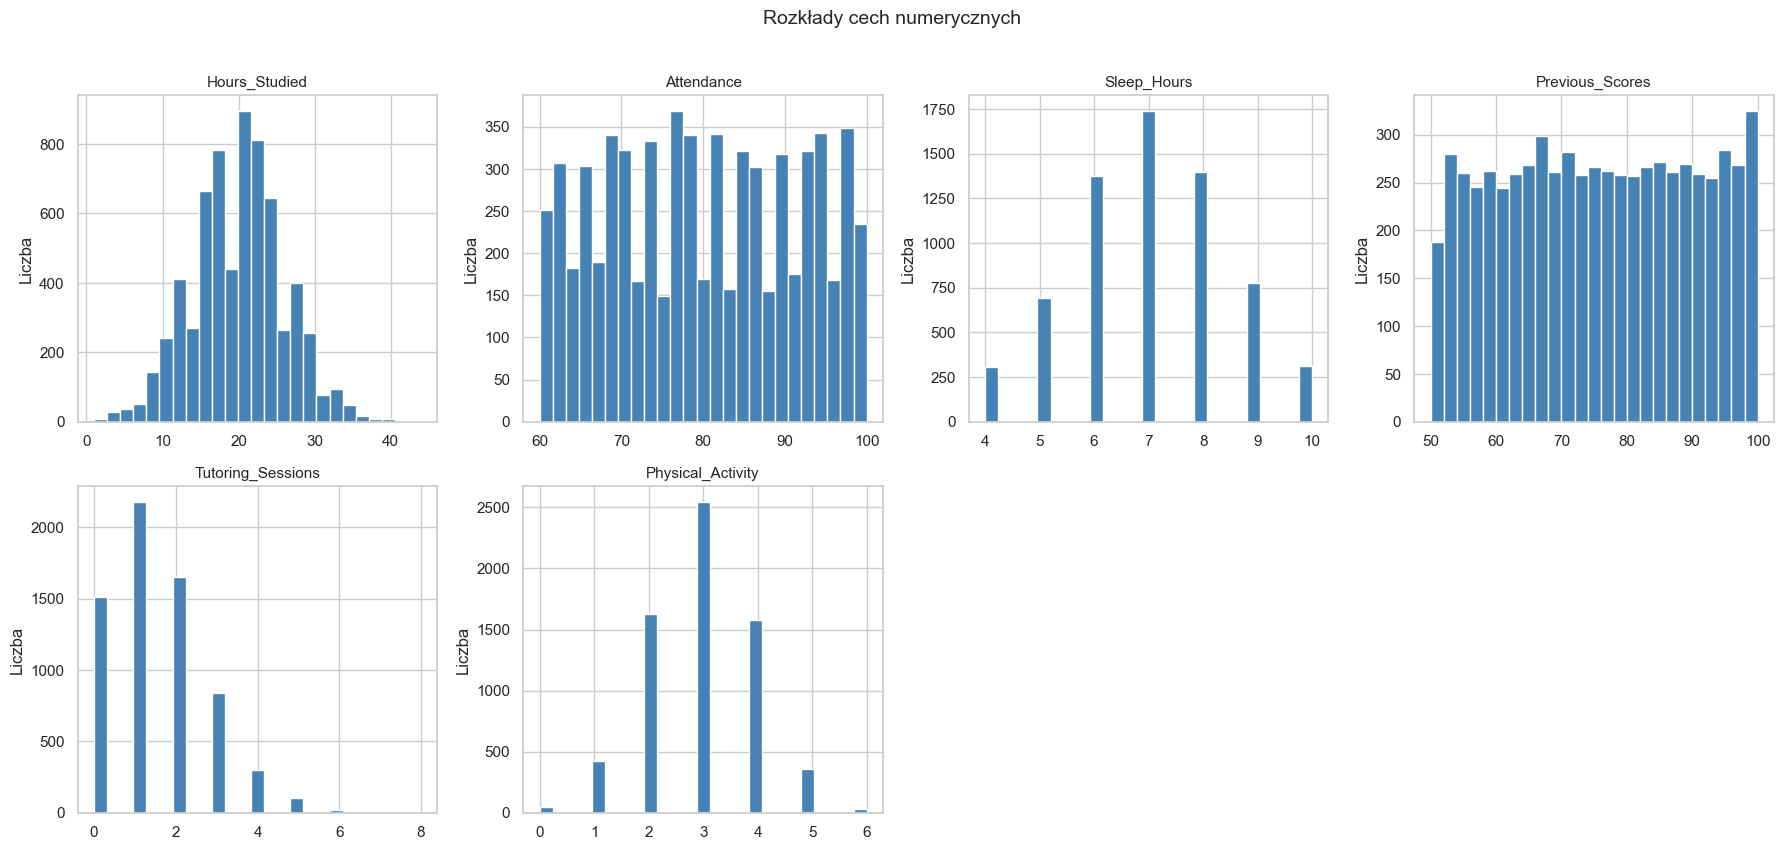

In [15]:
# Kolumny numeryczne (bez zmiennej docelowej)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != "Exam_Score"]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=25, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Liczba")

# Ukryj puste subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Rozkłady cech numerycznych", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../report/fig_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

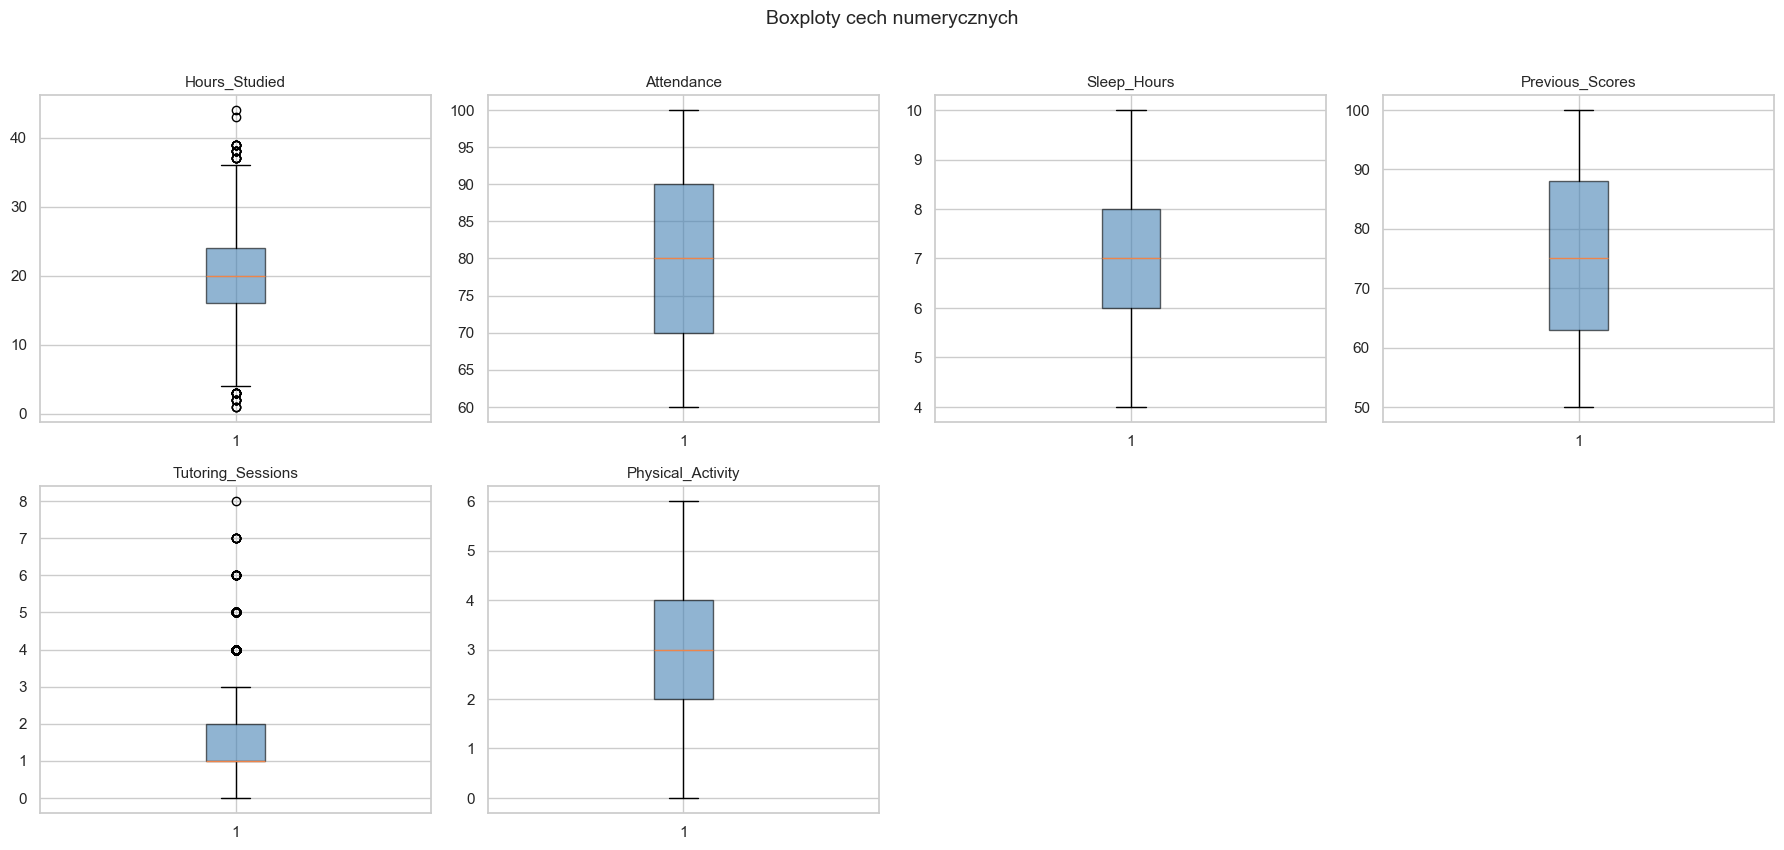

In [16]:
# Boxploty — wykrywanie wartości odstających (outliers)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6))
    axes[i].set_title(col, fontsize=11)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxploty cech numerycznych", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../report/fig_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Zmienne kategoryczne

In [17]:
# Kolumny kategoryczne (nowy pandas wymaga "str" zamiast "object")
cat_cols = df.select_dtypes(include="str").columns.tolist()
cat_cols = [c for c in cat_cols if c != "Pass"]

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}\n")
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts().to_string())
    print()

Categorical columns (13): ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

--- Parental_Involvement ---
Parental_Involvement
Medium    3362
High      1908
Low       1337

--- Access_to_Resources ---
Access_to_Resources
Medium    3319
High      1975
Low       1313

--- Extracurricular_Activities ---
Extracurricular_Activities
Yes    3938
No     2669

--- Motivation_Level ---
Motivation_Level
Medium    3351
Low       1937
High      1319

--- Internet_Access ---
Internet_Access
Yes    6108
No      499

--- Family_Income ---
Family_Income
Low       2672
Medium    2666
High      1269

--- Teacher_Quality ---
Teacher_Quality
Medium    3925
High      1947
Low        657

--- School_Type ---
School_Type
Public     4598
Private    2009

--- Peer_Influence ---
Peer_Influence
P

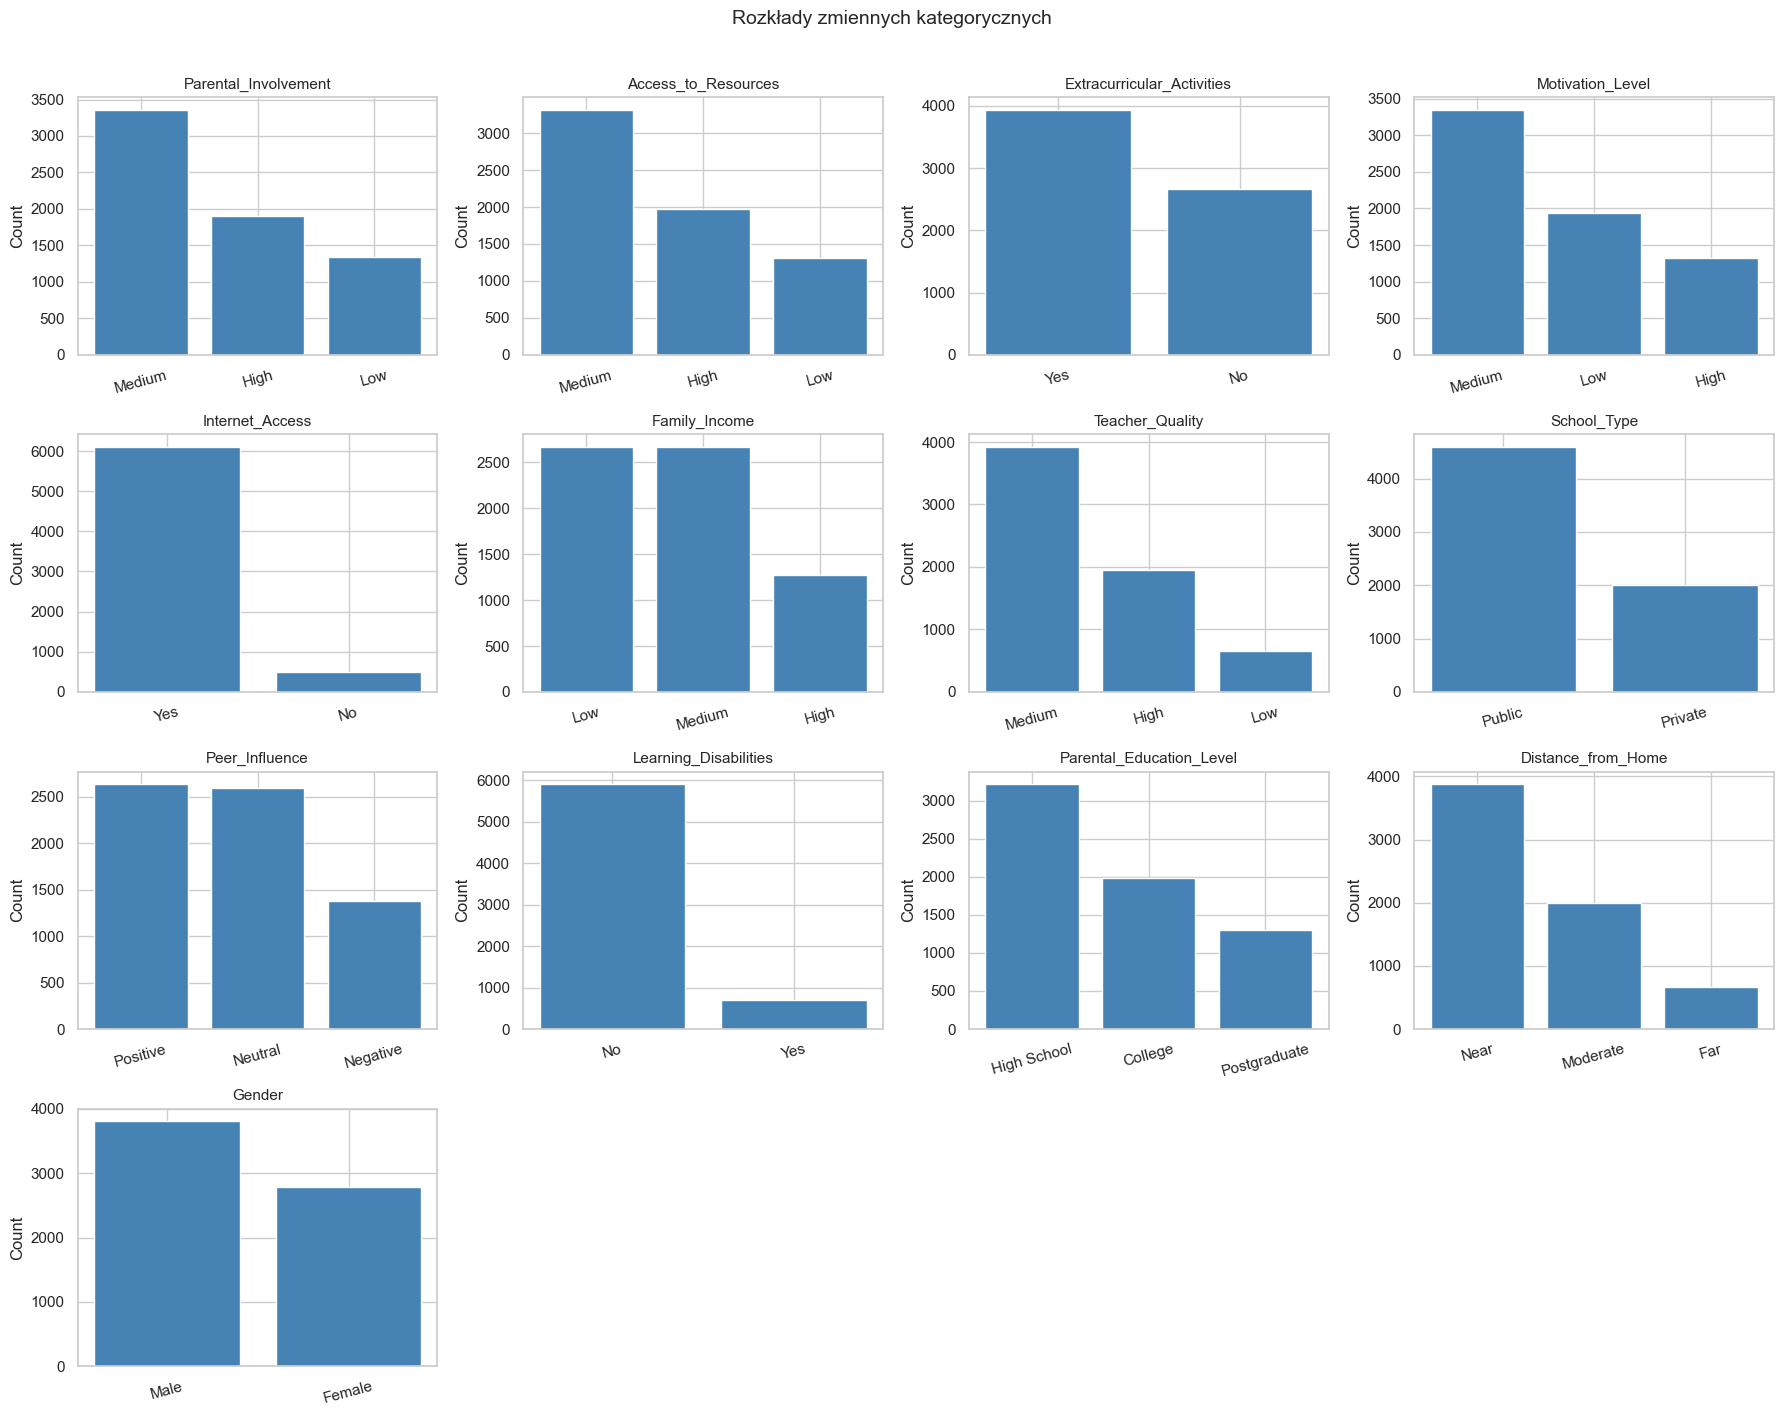

In [18]:
# Wykresy słupkowe — 13 kolumn, siatka 4x4
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=15)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Rozkłady zmiennych kategorycznych", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../report/fig_categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Macierz korelacji Pearsona

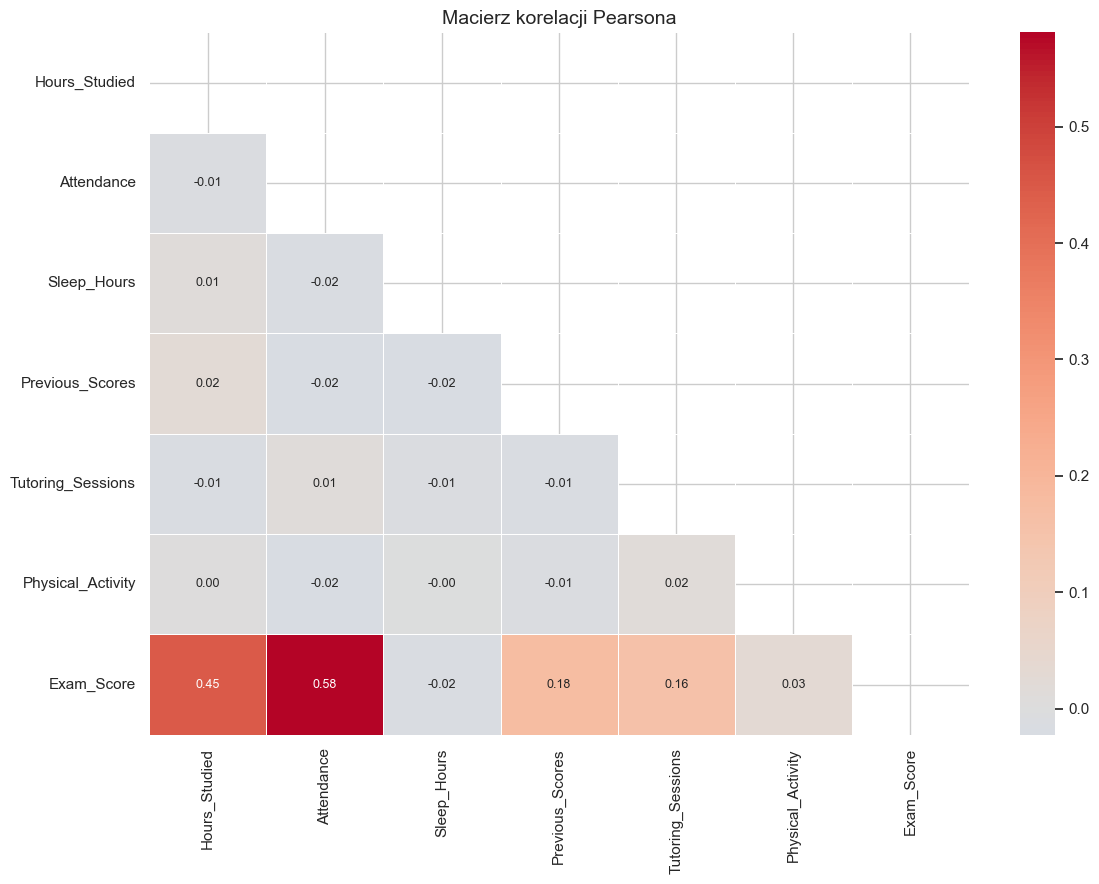


Najsilniejsze korelacje z Exam_Score:
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022


In [19]:
# Macierz korelacji — tylko kolumny numeryczne
corr_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # pokazujemy tylko dolny trójkąt
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title("Macierz korelacji Pearsona", fontsize=14)
plt.tight_layout()
plt.savefig("../report/fig_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Top korelacje z Exam_Score
print("\nNajsilniejsze korelacje z Exam_Score:")
print(corr_matrix["Exam_Score"].drop("Exam_Score").sort_values(ascending=False).to_string())

## 6. Kluczowe cechy vs Pass/Fail

C:\Users\kapus\AppData\Local\Temp\ipykernel_25016\3426705463.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([pass_vals, fail_vals], labels=["Pass", "Fail"],
C:\Users\kapus\AppData\Local\Temp\ipykernel_25016\3426705463.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([pass_vals, fail_vals], labels=["Pass", "Fail"],
C:\Users\kapus\AppData\Local\Temp\ipykernel_25016\3426705463.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([pass_vals, fail_vals], labels=["Pass", "Fail"],
C:\Users\kapus\AppData\Local\Temp\ipykernel_25016\3426705463.py:11: MatplotlibDeprecatio

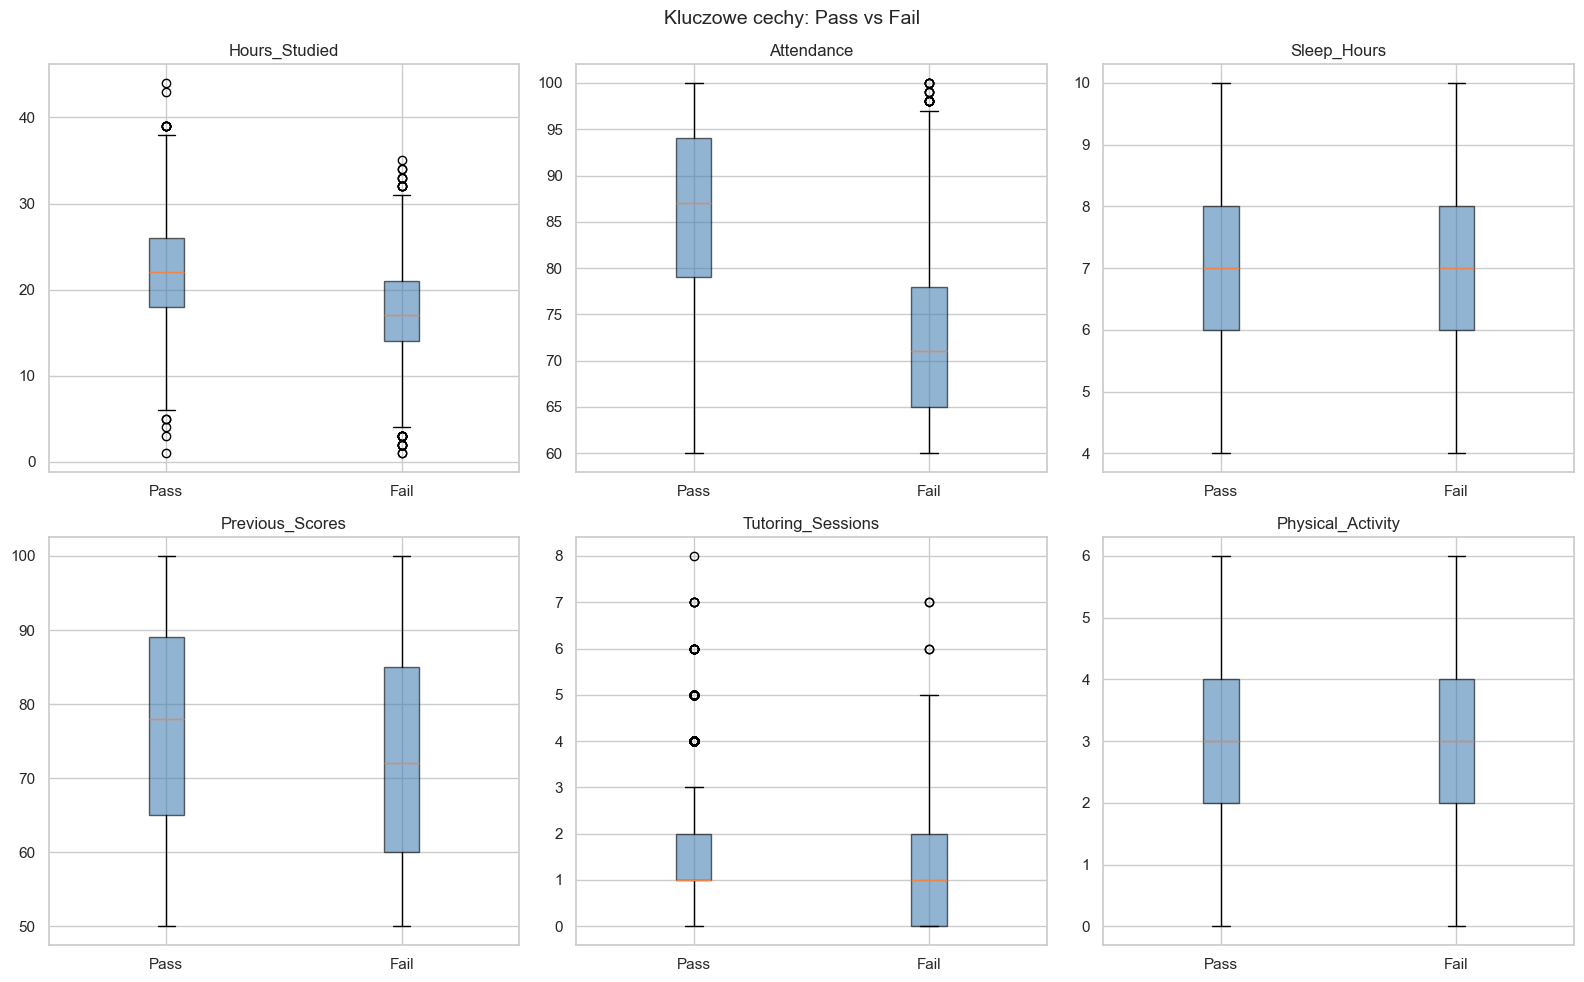

In [20]:
# Boxploty: cechy numeryczne vs Pass/Fail
key_features = ["Hours_Studied", "Attendance", "Sleep_Hours",
                "Previous_Scores", "Tutoring_Sessions", "Physical_Activity"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    pass_vals = df[df["Pass"] == "Pass"][col]
    fail_vals = df[df["Pass"] == "Fail"][col]
    axes[i].boxplot([pass_vals, fail_vals], labels=["Pass", "Fail"],
                    patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6))
    axes[i].set_title(col, fontsize=12)

plt.suptitle("Kluczowe cechy: Pass vs Fail", fontsize=14)
plt.tight_layout()
plt.savefig("../report/fig_features_vs_passfail.png", dpi=150, bbox_inches="tight")
plt.show()